# 🏢 중개사 신뢰도 모델 분석 보고서 (1회차)

이 노트북은 중개사 신뢰도 예측 모델의 전체 파이프라인 결과를 종합적으로 분석합니다.

## 목차
1. **데이터 개요** - 데이터 로드 및 기본 정보
2. **타겟 분포 분석** - A/B/C 등급 분포 시각화
3. **피처 분석** - 15개 피처 설명 및 중요도
4. **피처 상관관계 분석** - 상관관계 히트맵
5. **모델 비교 분석** - 5개 모델 + 앙상블 성능 비교
6. **결론 및 인사이트**

---

## 📦 1. 라이브러리 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 스타일
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


In [2]:
from pathlib import Path

# 절대 경로 설정
BASE_PATH = Path(r'c:\dev\study\eunjeong\SKN18-FINAL-1TEAM')
DATA_PATH = BASE_PATH / 'data' / 'ML'
MODEL_PATH = BASE_PATH / 'apps' / 'reco' / 'models' / 'trust_model' / 'save_models'

# 데이터 로드
df_features = pd.read_csv(DATA_PATH / 'office_features.csv', encoding='utf-8-sig')
df_target = pd.read_csv(DATA_PATH / 'office_target.csv', encoding='utf-8-sig')

# 모델 로드
with open(MODEL_PATH / 'temp_trained_models.pkl', 'rb') as f:
    model_data = pickle.load(f)

print(f'📊 피처 데이터: {df_features.shape}')
print(f'📊 타겟 데이터: {df_target.shape}')
print(f'📊 모델 수: {len(model_data["models"])}개')

📊 피처 데이터: (351, 46)
📊 타겟 데이터: (351, 31)
📊 모델 수: 5개


---
## 📊 2. 타겟 분포 분석

### 2.1 타겟 생성 방법

타겟 변수는 **Z-score 기반 분위수**를 사용하여 생성되었습니다:

1. **거래성사율 계산**: `거래완료 / (거래완료 + 등록매물)`
2. **지역별 정규화**: 지역별 평균과 표준편차를 사용한 Z-score 계산
3. **등급 분류 (30/40/30 분포)**:
   - **A등급 (상위 30%)**: Z-score > 70% 분위수 → 우수 중개사
   - **B등급 (중간 40%)**: 30% ≤ Z-score ≤ 70% 분위수 → 보통 중개사
   - **C등급 (하위 30%)**: Z-score < 30% 분위수 → 개선 필요 중개사

In [3]:
# 타겟 분포 확인
target_dist = df_target['신뢰도등급'].value_counts().sort_index()
target_pct = df_target['신뢰도등급'].value_counts(normalize=True).sort_index() * 100

print('=' * 50)
print('📌 신뢰도 등급 분포')
print('=' * 50)
for grade in ['A', 'B', 'C']:
    count = target_dist.get(grade, 0)
    pct = target_pct.get(grade, 0)
    print(f'  {grade}등급: {count:3d}개 ({pct:5.1f}%)')
print(f'\n  총합: {len(df_target)}개 (100.0%)')

📌 신뢰도 등급 분포
  A등급: 106개 ( 30.2%)
  B등급: 140개 ( 39.9%)
  C등급: 105개 ( 29.9%)

  총합: 351개 (100.0%)


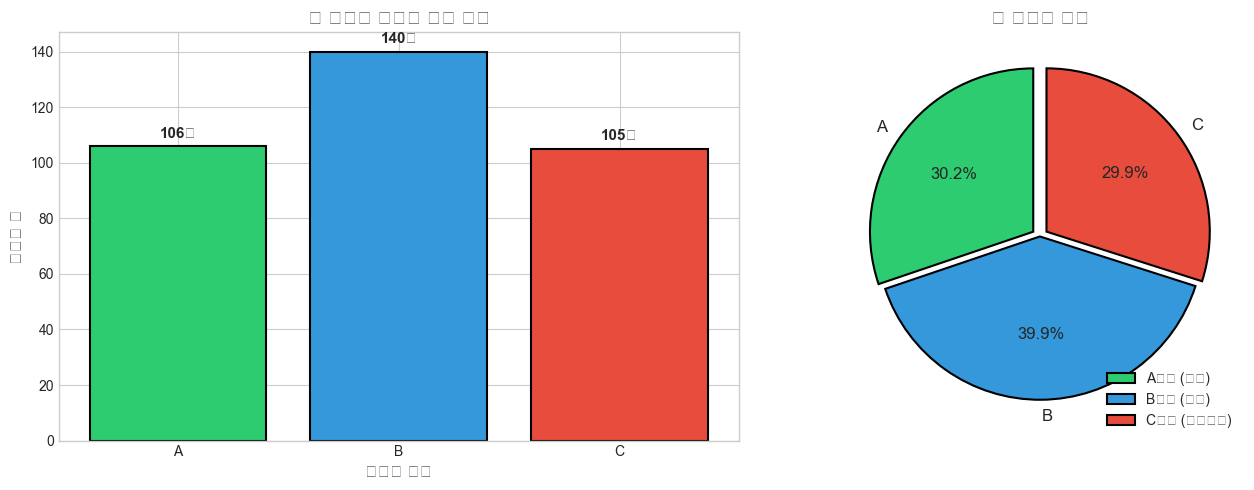

💾 그래프 저장: target_distribution.png


In [4]:
# 타겟 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 막대 그래프
colors = ['#2ecc71', '#3498db', '#e74c3c']  # A=초록, B=파랑, C=빨강
grades = ['A', 'B', 'C']
counts = [target_dist.get(g, 0) for g in grades]

ax1 = axes[0]
bars = ax1.bar(grades, counts, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('신뢰도 등급', fontsize=12)
ax1.set_ylabel('중개사 수', fontsize=12)
ax1.set_title('🏢 중개사 신뢰도 등급 분포', fontsize=14, fontweight='bold')

# 막대 위에 숫자 표시
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{count}개', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. 파이 차트
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts, labels=grades, colors=colors, autopct='%1.1f%%',
    startangle=90, explode=(0.05, 0, 0.05),
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5},
    textprops={'fontsize': 12}
)
ax2.set_title('📊 등급별 비율', fontsize=14, fontweight='bold')

# 범례 추가
legend_labels = ['A등급 (우수)', 'B등급 (보통)', 'C등급 (개선필요)']
ax2.legend(wedges, legend_labels, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('💾 그래프 저장: target_distribution.png')

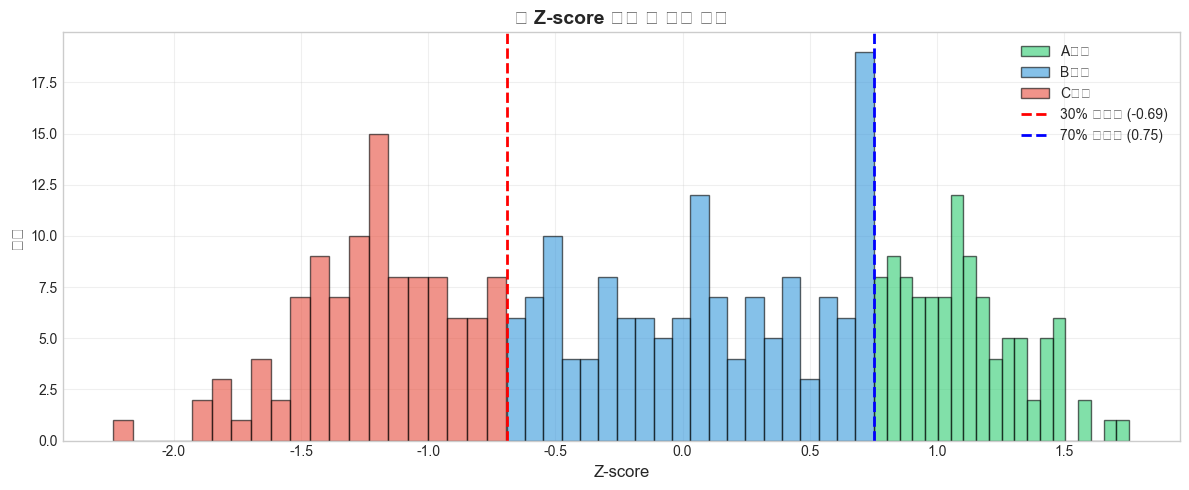


📌 등급 경계값:
   C등급: Z-score ≤ -0.6917
   B등급: -0.6917 < Z-score ≤ 0.7523
   A등급: Z-score > 0.7523


In [5]:
# Z-score 분포 시각화
fig, ax = plt.subplots(figsize=(12, 5))

# Z-score 히스토그램
for grade, color in zip(['A', 'B', 'C'], colors):
    data = df_target[df_target['신뢰도등급'] == grade]['Zscore']
    ax.hist(data, bins=20, alpha=0.6, color=color, label=f'{grade}등급', edgecolor='black')

# 분위수 경계선
q30 = df_target['Zscore'].quantile(0.30)
q70 = df_target['Zscore'].quantile(0.70)

ax.axvline(q30, color='red', linestyle='--', linewidth=2, label=f'30% 분위수 ({q30:.2f})')
ax.axvline(q70, color='blue', linestyle='--', linewidth=2, label=f'70% 분위수 ({q70:.2f})')

ax.set_xlabel('Z-score', fontsize=12)
ax.set_ylabel('빈도', fontsize=12)
ax.set_title('📈 Z-score 분포 및 등급 경계', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('zscore_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 등급 경계값:')
print(f'   C등급: Z-score ≤ {q30:.4f}')
print(f'   B등급: {q30:.4f} < Z-score ≤ {q70:.4f}')
print(f'   A등급: Z-score > {q70:.4f}')

---
## 🔧 3. 피처(Feature) 분석

### 3.1 피처 설명

총 **15개의 피처**가 사용되며, 4개 카테고리로 분류됩니다:

In [6]:
# 피처 정의 및 설명
feature_info = {
    '거래 지표 (3개)': {
        '거래완료_safe': 'log(1 + 거래완료 건수) - 로그 변환으로 극단값 영향 감소',
        '등록매물_safe': 'log(1 + 등록매물 건수) - 로그 변환으로 극단값 영향 감소',
        '총거래활동량': 'log(1 + 거래완료 + 등록매물) - 전체 거래 활동량'
    },
    '인력 지표 (4개)': {
        '총_직원수': '공인중개사 + 중개보조원 + 일반직원 수',
        '공인중개사수': '등록된 공인중개사 수',
        '공인중개사_비율': '전체 직원 중 공인중개사 비율',
        '중개보조원_비율': '전체 직원 중 중개보조원 비율'
    },
    '운영 경험 (5개)': {
        '운영기간_년': '사업자 등록일로부터 현재까지 운영 기간(년)',
        '운영경험_지수': 'exp(운영기간_년 / 10) - 지수적 경험 가중치',
        '숙련도_지수': '운영기간_년 × 공인중개사_비율',
        '운영_안정성': '운영기간 3년 이상 여부 (0/1)',
        '베테랑': '운영기간 5년 이상 여부 (0/1)'
    },
    '조직 구조 (3개)': {
        '대형사무소': '총 직원수 3명 이상 여부 (0/1)',
        '직책_다양성': '보유한 직책 종류 수 (0~4)',
        '경력_규모_지수': '운영기간_년 × 총_직원수 - 경력과 규모 시너지'
    }
}

print('=' * 70)
print('📋 피처(Feature) 상세 설명 - 총 15개')
print('=' * 70)

idx = 1
for category, features in feature_info.items():
    print(f'\n📁 {category}')
    print('-' * 60)
    for name, desc in features.items():
        print(f'   {idx:2d}. {name}')
        print(f'       └ {desc}')
        idx += 1

📋 피처(Feature) 상세 설명 - 총 15개

📁 거래 지표 (3개)
------------------------------------------------------------
    1. 거래완료_safe
       └ log(1 + 거래완료 건수) - 로그 변환으로 극단값 영향 감소
    2. 등록매물_safe
       └ log(1 + 등록매물 건수) - 로그 변환으로 극단값 영향 감소
    3. 총거래활동량
       └ log(1 + 거래완료 + 등록매물) - 전체 거래 활동량

📁 인력 지표 (4개)
------------------------------------------------------------
    4. 총_직원수
       └ 공인중개사 + 중개보조원 + 일반직원 수
    5. 공인중개사수
       └ 등록된 공인중개사 수
    6. 공인중개사_비율
       └ 전체 직원 중 공인중개사 비율
    7. 중개보조원_비율
       └ 전체 직원 중 중개보조원 비율

📁 운영 경험 (5개)
------------------------------------------------------------
    8. 운영기간_년
       └ 사업자 등록일로부터 현재까지 운영 기간(년)
    9. 운영경험_지수
       └ exp(운영기간_년 / 10) - 지수적 경험 가중치
   10. 숙련도_지수
       └ 운영기간_년 × 공인중개사_비율
   11. 운영_안정성
       └ 운영기간 3년 이상 여부 (0/1)
   12. 베테랑
       └ 운영기간 5년 이상 여부 (0/1)

📁 조직 구조 (3개)
------------------------------------------------------------
   13. 대형사무소
       └ 총 직원수 3명 이상 여부 (0/1)
   14. 직책_다양성
       └ 보유한 직책 종류 수 (0~4)
   15. 경력_규모_지수


In [7]:
# 피처 목록 정의
feature_cols = [
    '거래완료_safe', '등록매물_safe', '총거래활동량',
    '총_직원수', '공인중개사수', '공인중개사_비율', '중개보조원_비율',
    '운영기간_년', '운영경험_지수', '숙련도_지수', '운영_안정성', '베테랑',
    '대형사무소', '직책_다양성', '경력_규모_지수'
]

# 피처 통계
X = df_features[feature_cols].copy()

print('📊 피처 기본 통계량')
print('=' * 80)
display(X.describe().T.round(3))

📊 피처 기본 통계량


,count,mean,std,min,25%,50%,75%,max
거래완료_safe,351.0,3.598,1.981,0.000,2.197,3.689,5.043,8.113
등록매물_safe,351.0,3.345,1.110,0.693,2.398,3.178,4.119,6.397
총거래활동량,351.0,4.501,1.404,0.693,3.526,4.443,5.412,8.173
총_직원수,351.0,7.812,8.913,0.000,3.000,5.000,9.500,80.000
공인중개사수,351.0,1.909,1.715,0.000,1.000,1.000,2.000,13.000
공인중개사_비율,351.0,0.413,0.318,0.000,0.182,0.333,0.600,1.000
중개보조원_비율,351.0,0.241,0.170,0.000,0.000,0.333,0.386,0.500
운영기간_년,351.0,5.892,6.454,0.126,1.457,3.847,7.926,41.511
운영경험_지수,351.0,2.620,5.186,1.013,1.157,1.469,2.209,63.506
숙련도_지수,351.0,2.541,3.744,0.000,0.301,1.109,3.215,23.912


### 3.2 피처 분포 시각화

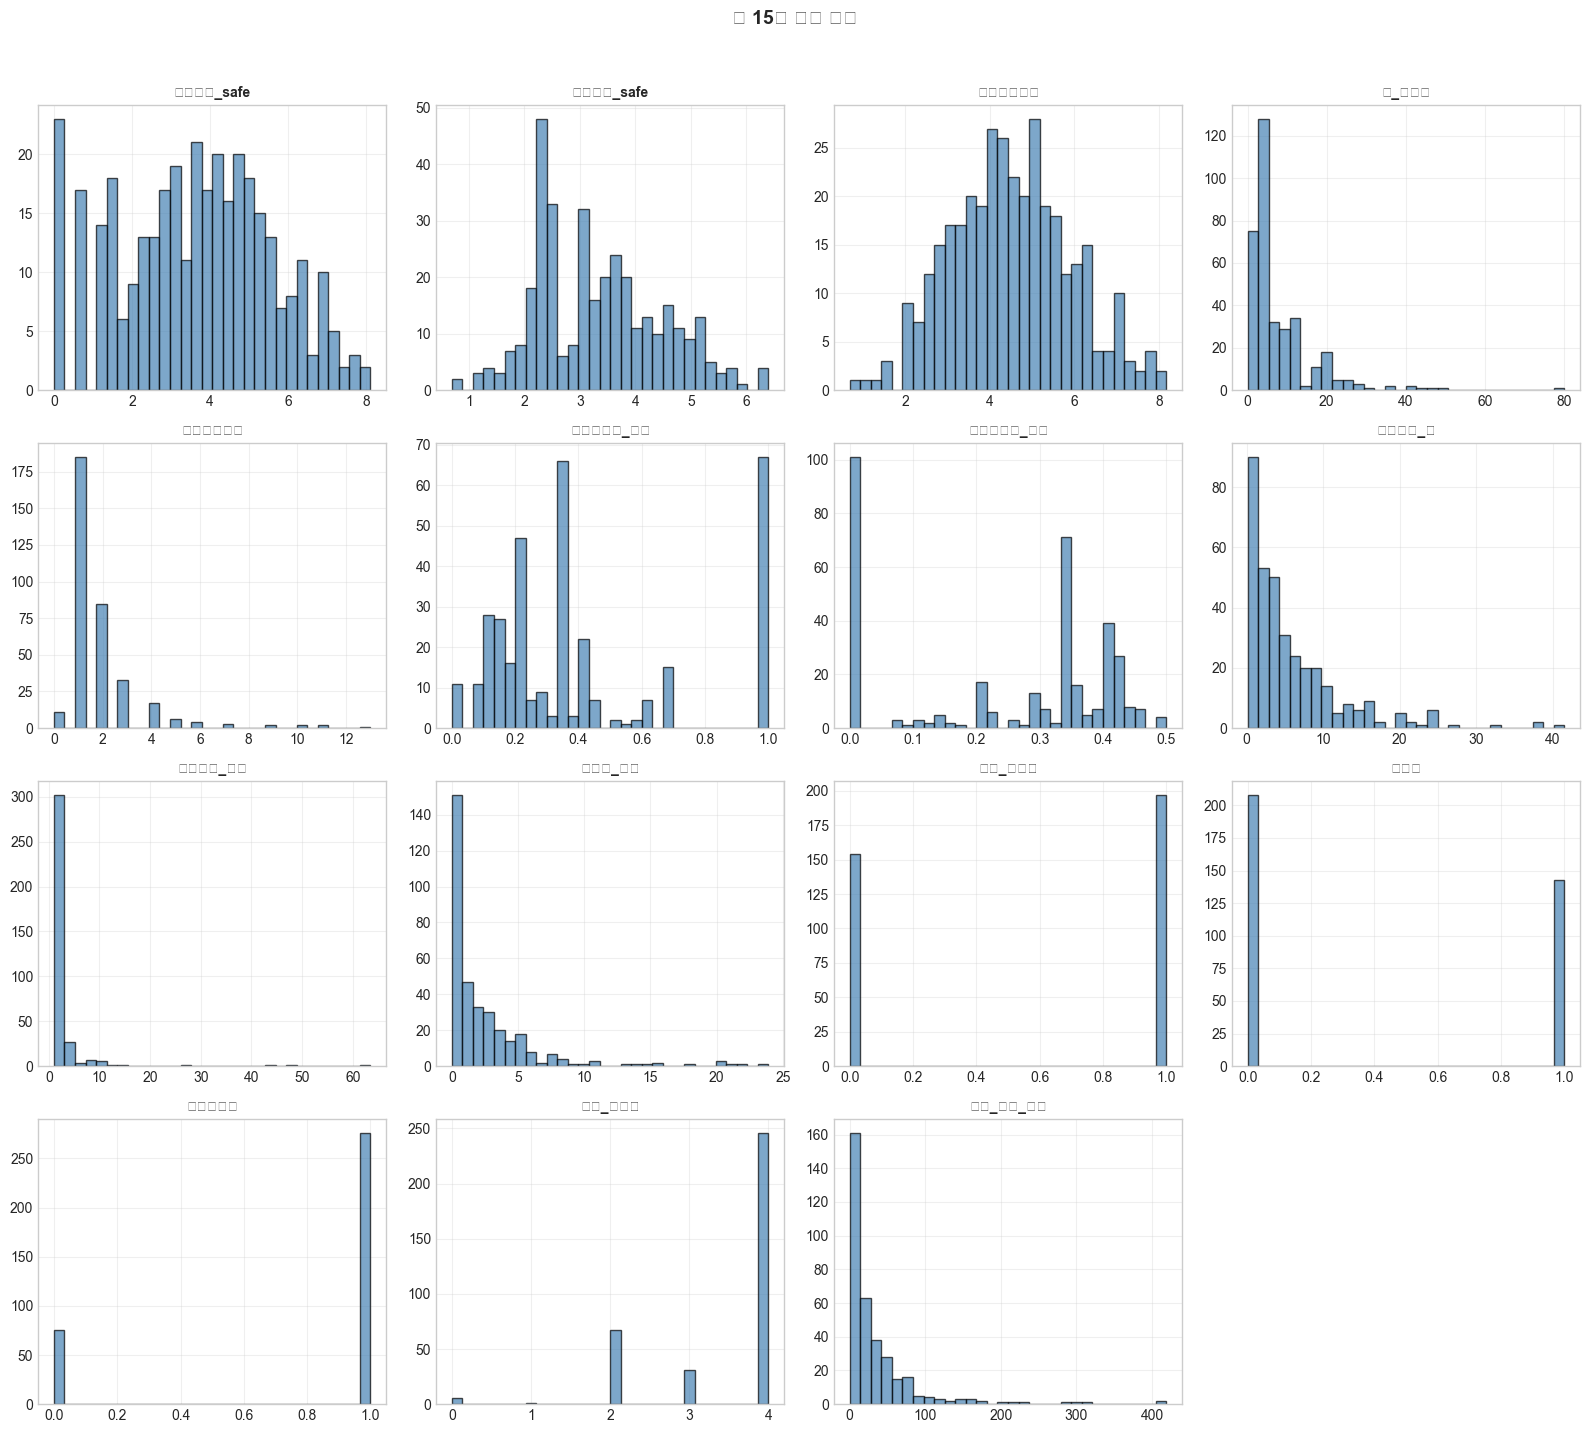

In [8]:
# 피처 분포 히스토그램
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    ax.hist(X[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)

# 빈 subplot 제거
for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('📊 15개 피처 분포', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔗 4. 피처 상관관계 분석

피처 간의 상관관계를 분석하여 다중공선성 여부를 확인합니다.

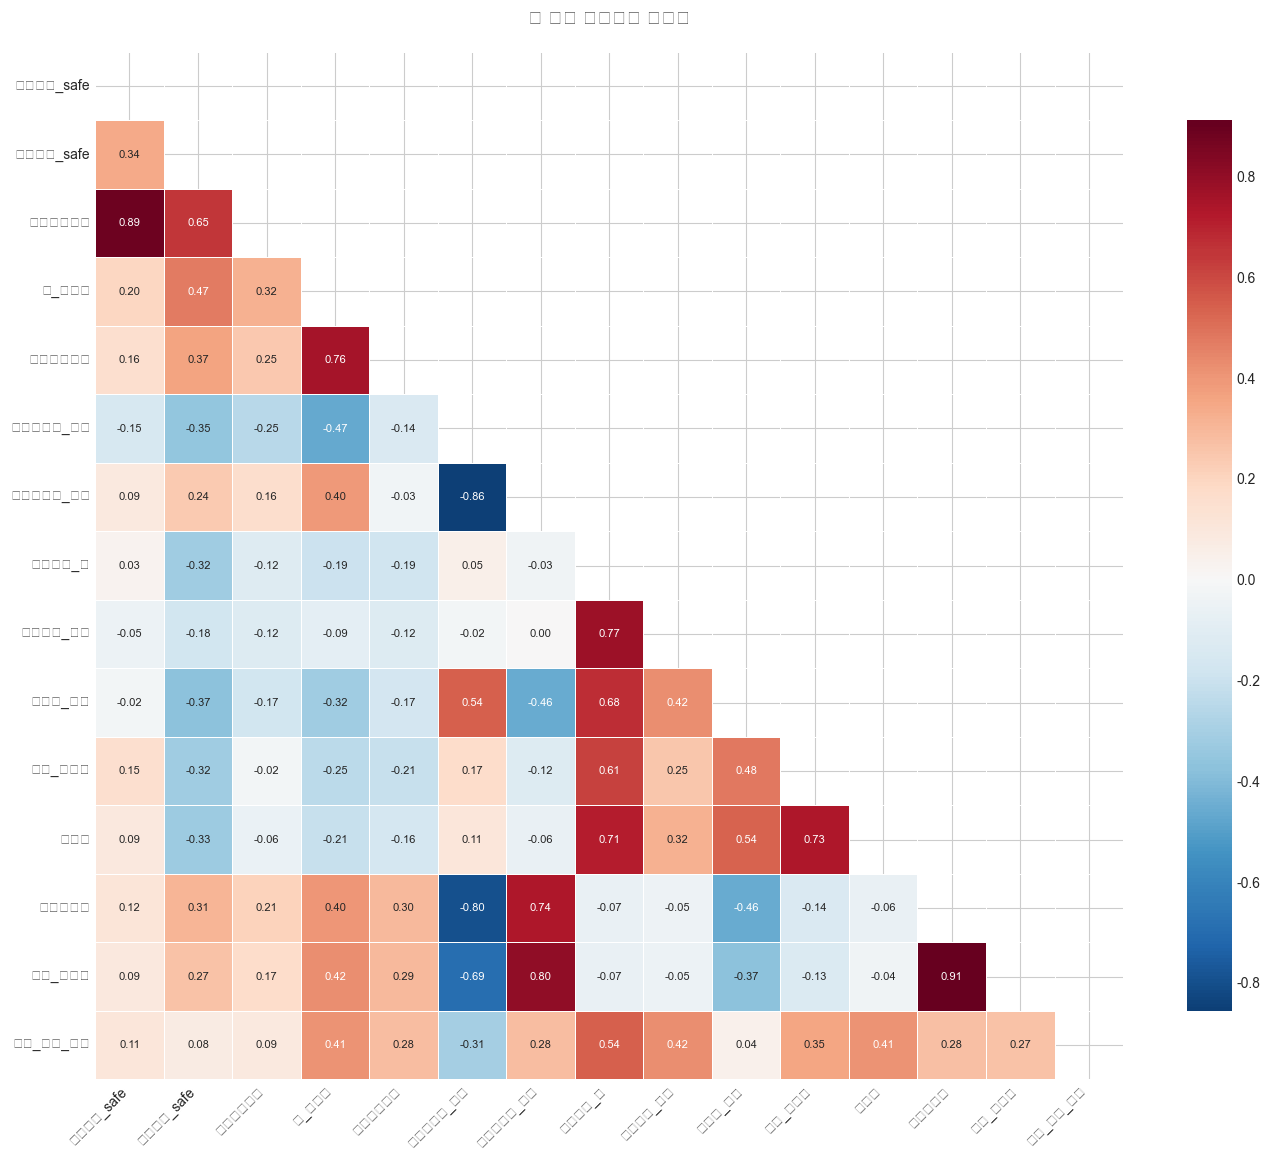

In [9]:
# 상관관계 히트맵
plt.figure(figsize=(14, 12))

corr_matrix = X.corr()

# 마스크 생성 (상삼각행렬만 표시)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)

plt.title('🔗 피처 상관관계 히트맵', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# 높은 상관관계 쌍 찾기
print('📊 높은 상관관계 피처 쌍 (|r| > 0.7)')
print('=' * 60)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_val
            ))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

if high_corr_pairs:
    for f1, f2, r in high_corr_pairs:
        print(f'   • {f1} ↔ {f2}: r = {r:.3f}')
else:
    print('   ✅ 높은 상관관계(|r| > 0.7)를 가진 피처 쌍이 없습니다.')

print('\n💡 인사이트:')
print('   - 높은 상관관계는 다중공선성 문제를 야기할 수 있습니다.')
print('   - 하지만 트리 기반 모델(RF, XGBoost, CatBoost)은 상관관계에 강건합니다.')

📊 높은 상관관계 피처 쌍 (|r| > 0.7)
   • 대형사무소 ↔ 직책_다양성: r = 0.911
   • 거래완료_safe ↔ 총거래활동량: r = 0.890
   • 공인중개사_비율 ↔ 중개보조원_비율: r = -0.855
   • 중개보조원_비율 ↔ 직책_다양성: r = 0.802
   • 공인중개사_비율 ↔ 대형사무소: r = -0.797
   • 운영기간_년 ↔ 운영경험_지수: r = 0.774
   • 총_직원수 ↔ 공인중개사수: r = 0.758
   • 중개보조원_비율 ↔ 대형사무소: r = 0.737
   • 운영_안정성 ↔ 베테랑: r = 0.733
   • 운영기간_년 ↔ 베테랑: r = 0.714

💡 인사이트:
   - 높은 상관관계는 다중공선성 문제를 야기할 수 있습니다.
   - 하지만 트리 기반 모델(RF, XGBoost, CatBoost)은 상관관계에 강건합니다.


---
## 🤖 5. 모델 비교 분석

### 5.1 사용된 모델 설명

총 **5개의 개별 모델 + 1개의 앙상블 모델**이 사용되었습니다:

In [12]:
model_descriptions = {
    'LogisticRegression': {
        '설명': '선형 분류 모델로, 로지스틱 함수를 사용하여 클래스 확률을 예측',
        '특성': [
            '해석 가능성이 높음 (계수 분석 가능)',
            '학습 속도가 빠름',
            '과적합에 강건함 (정규화 적용)',
            'class_weight="balanced"로 클래스 불균형 처리'
        ],
        '하이퍼파라미터': 'C=0.5, max_iter=1000',
        '선택 이유': '베이스라인 모델로 활용, 해석 가능성 및 과적합 방지'
    },
    'RandomForest': {
        '설명': '여러 결정 트리를 배깅(Bagging)하여 앙상블하는 모델',
        '특성': [
            '피처 중요도 산출 가능',
            '비선형 관계 학습 가능',
            '과적합 방지를 위해 depth 제한',
            '병렬 처리로 학습 속도 빠름'
        ],
        '하이퍼파라미터': 'n_estimators=200, max_depth=4, min_samples_split=15, min_samples_leaf=5',
        '선택 이유': '비선형 패턴 포착 및 피처 중요도 분석'
    },
    'XGBoost': {
        '설명': '그래디언트 부스팅 기반의 고성능 앙상블 모델',
        '특성': [
            '정규화 내장 (L1, L2)',
            '결측치 자동 처리',
            '조기 종료(Early Stopping) 지원',
            '높은 예측 성능'
        ],
        '하이퍼파라미터': 'n_estimators=200, max_depth=3, learning_rate=0.05, reg_lambda=2.0, reg_alpha=0.5',
        '선택 이유': '높은 예측 성능과 정규화로 과적합 방지'
    },
    'CatBoost': {
        '설명': '범주형 변수에 최적화된 그래디언트 부스팅 모델',
        '특성': [
            '범주형 변수 자동 처리',
            '순서 기반 부스팅으로 과적합 방지',
            'GPU 학습 지원',
            '파라미터 튜닝 없이도 좋은 성능'
        ],
        '하이퍼파라미터': 'iterations=200, depth=3, learning_rate=0.05, l2_leaf_reg=5.0',
        '선택 이유': '범주형 변수 처리 및 과적합 방지'
    },
    'Ensemble': {
        '설명': 'VotingClassifier를 사용한 소프트 보팅 앙상블',
        '특성': [
            '여러 모델의 예측 확률을 평균',
            '개별 모델의 약점 보완',
            '일반화 성능 향상',
            '다양성을 통한 안정성'
        ],
        '하이퍼파라미터': 'voting="soft"',
        '선택 이유': '여러 모델 장점을 결합하여 안정적인 예측'
    }
}

print('=' * 80)
print('🤖 모델별 상세 설명')
print('=' * 80)

for model_name, info in model_descriptions.items():
    print(f'\n📌 {model_name}')
    print(f'   설명: {info["설명"]}')
    print(f'   하이퍼파라미터: {info["하이퍼파라미터"]}')
    print(f'   선택 이유: {info["선택 이유"]}')
    print('   특성:')
    for char in info['특성']:
        print(f'      • {char}')

🤖 모델별 상세 설명

📌 LogisticRegression
   설명: 선형 분류 모델로, 로지스틱 함수를 사용하여 클래스 확률을 예측
   하이퍼파라미터: C=0.5, max_iter=1000
   선택 이유: 베이스라인 모델로 활용, 해석 가능성 및 과적합 방지
   특성:
      • 해석 가능성이 높음 (계수 분석 가능)
      • 학습 속도가 빠름
      • 과적합에 강건함 (정규화 적용)
      • class_weight="balanced"로 클래스 불균형 처리

📌 RandomForest
   설명: 여러 결정 트리를 배깅(Bagging)하여 앙상블하는 모델
   하이퍼파라미터: n_estimators=200, max_depth=4, min_samples_split=15, min_samples_leaf=5
   선택 이유: 비선형 패턴 포착 및 피처 중요도 분석
   특성:
      • 피처 중요도 산출 가능
      • 비선형 관계 학습 가능
      • 과적합 방지를 위해 depth 제한
      • 병렬 처리로 학습 속도 빠름

📌 XGBoost
   설명: 그래디언트 부스팅 기반의 고성능 앙상블 모델
   하이퍼파라미터: n_estimators=200, max_depth=3, learning_rate=0.05, reg_lambda=2.0, reg_alpha=0.5
   선택 이유: 높은 예측 성능과 정규화로 과적합 방지
   특성:
      • 정규화 내장 (L1, L2)
      • 결측치 자동 처리
      • 조기 종료(Early Stopping) 지원
      • 높은 예측 성능

📌 CatBoost
   설명: 범주형 변수에 최적화된 그래디언트 부스팅 모델
   하이퍼파라미터: iterations=200, depth=3, learning_rate=0.05, l2_leaf_reg=5.0
   선택 이유: 범주형 변수 처리 및 과적합 방지
   특성:
      • 범주형 변수 자동 처리
      • 순서

### 5.2 모델 성능 비교

In [13]:
# CV 결과 로드
cv_results = model_data.get('cv_results', {})

# 성능 테이블 생성
performance_data = []

for name, results in cv_results.items():
    performance_data.append({
        '모델': name,
        'Train Accuracy': results['train_acc'],
        'Test Accuracy': results['test_acc'],
        '과적합률': results['train_acc'] - results['test_acc'],
        'CV Mean': results['cv_mean'],
        'CV Std': results['cv_std']
    })

perf_df = pd.DataFrame(performance_data)
perf_df = perf_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print('📊 모델 성능 비교표')
print('=' * 90)
display(perf_df.style.format({
    'Train Accuracy': '{:.4f}',
    'Test Accuracy': '{:.4f}',
    '과적합률': '{:.4f}',
    'CV Mean': '{:.4f}',
    'CV Std': '{:.4f}'
}).background_gradient(subset=['Test Accuracy'], cmap='Greens'))

📊 모델 성능 비교표


,모델,Train Accuracy,Test Accuracy,과적합률,CV Mean,CV Std
0,LogisticRegression,0.8714,0.8732,-0.0018,0.8250,0.0510
1,Ensemble,0.9036,0.8310,0.0726,0.7964,0.0614
2,XGBoost,0.9429,0.8169,0.1260,0.7857,0.0649
3,CatBoost,0.8571,0.8169,0.0402,0.7786,0.0720
4,RandomForest,0.8071,0.6901,0.1170,0.6679,0.0693


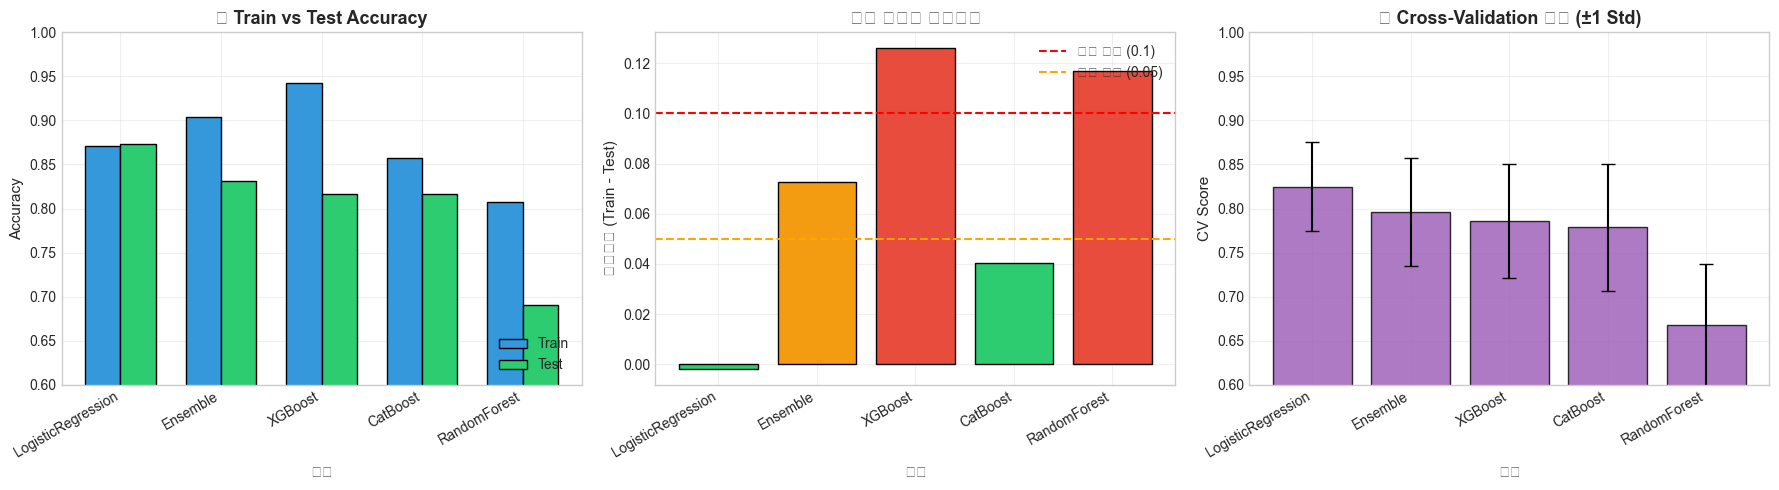

💾 그래프 저장: model_comparison.png


In [14]:
# 모델 성능 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = perf_df['모델'].tolist()
x = np.arange(len(models))
width = 0.35

# 1. Train vs Test Accuracy
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, perf_df['Train Accuracy'], width, label='Train', color='#3498db', edgecolor='black')
bars2 = ax1.bar(x + width/2, perf_df['Test Accuracy'], width, label='Test', color='#2ecc71', edgecolor='black')
ax1.set_xlabel('모델', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('📊 Train vs Test Accuracy', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=30, ha='right')
ax1.legend(loc='lower right')
ax1.set_ylim([0.6, 1.0])
ax1.grid(True, alpha=0.3)

# 2. 과적합률
ax2 = axes[1]
colors_overfitting = ['#e74c3c' if v > 0.1 else '#f39c12' if v > 0.05 else '#2ecc71' for v in perf_df['과적합률']]
bars3 = ax2.bar(models, perf_df['과적합률'], color=colors_overfitting, edgecolor='black')
ax2.axhline(y=0.1, color='red', linestyle='--', label='위험 기준 (0.1)')
ax2.axhline(y=0.05, color='orange', linestyle='--', label='주의 기준 (0.05)')
ax2.set_xlabel('모델', fontsize=11)
ax2.set_ylabel('과적합률 (Train - Test)', fontsize=11)
ax2.set_title('⚠️ 모델별 과적합률', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right')
ax2.set_xticklabels(models, rotation=30, ha='right')
ax2.grid(True, alpha=0.3)

# 3. CV Score with Error Bars
ax3 = axes[2]
ax3.bar(models, perf_df['CV Mean'], yerr=perf_df['CV Std'], capsize=5,
        color='#9b59b6', edgecolor='black', alpha=0.8)
ax3.set_xlabel('모델', fontsize=11)
ax3.set_ylabel('CV Score', fontsize=11)
ax3.set_title('🔄 Cross-Validation 점수 (±1 Std)', fontsize=13, fontweight='bold')
ax3.set_xticklabels(models, rotation=30, ha='right')
ax3.set_ylim([0.6, 1.0])
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('💾 그래프 저장: model_comparison.png')

### 5.3 피처 중요도 분석

In [15]:
# 피처 중요도 추출 (RandomForest, XGBoost, CatBoost)
models = model_data['models']
feature_names = model_data['feature_names']

importance_data = pd.DataFrame({'Feature': feature_names})

# RandomForest
if 'RandomForest' in models:
    importance_data['RandomForest'] = models['RandomForest'].feature_importances_

# XGBoost
if 'XGBoost' in models:
    importance_data['XGBoost'] = models['XGBoost'].feature_importances_

# CatBoost
if 'CatBoost' in models:
    importance_data['CatBoost'] = models['CatBoost'].feature_importances_

# 평균 중요도
importance_cols = [c for c in importance_data.columns if c != 'Feature']
importance_data['평균'] = importance_data[importance_cols].mean(axis=1)
importance_data = importance_data.sort_values('평균', ascending=False).reset_index(drop=True)

print('📊 피처 중요도 (트리 기반 모델)')
print('=' * 70)
display(importance_data.style.format({
    'RandomForest': '{:.4f}',
    'XGBoost': '{:.4f}',
    'CatBoost': '{:.4f}',
    '평균': '{:.4f}'
}).background_gradient(subset=['평균'], cmap='YlOrRd'))

📊 피처 중요도 (트리 기반 모델)


,Feature,RandomForest,XGBoost,CatBoost,평균
0,거래완료_safe,0.3913,0.3684,62.9151,21.2249
1,등록매물_safe,0.0698,0.1537,19.7306,6.6514
2,총거래활동량,0.1840,0.1178,5.9085,2.0701
3,운영경험_지수,0.0781,0.0000,2.3836,0.8206
4,경력_규모_지수,0.0526,0.0490,2.0390,0.7135
5,운영기간_년,0.0718,0.0512,1.4698,0.5309
6,숙련도_지수,0.0416,0.0591,1.1517,0.4175
7,총_직원수,0.0282,0.0483,0.7499,0.2755
8,운영_안정성,0.0266,0.0000,0.7395,0.2554
9,공인중개사_비율,0.0136,0.0408,0.6819,0.2455


In [ ]:
# 피처 중요도 시각화
fig, ax = plt.subplots(figsize=(12, 8))

y_pos = np.arange(len(importance_data))
ax.barh(y_pos, importance_data['평균'], color='steelblue', edgecolor='black', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(importance_data['Feature'])
ax.invert_yaxis()  # 가장 중요한 피처가 위에 오도록
ax.set_xlabel('평균 중요도', fontsize=12)
ax.set_title('🏆 피처 중요도 순위 (트리 기반 모델 평균)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 값 표시
for i, v in enumerate(importance_data['평균']):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('💾 그래프 저장: feature_importance.png')

### 5.4 Logistic Regression 계수 분석

In [16]:
# LogisticRegression 계수
if 'LogisticRegression' in models:
    lr_model = models['LogisticRegression']
    
    # 다중 클래스이므로 각 클래스별 계수
    coef_df = pd.DataFrame(
        lr_model.coef_.T,
        index=feature_names,
        columns=['A등급', 'B등급', 'C등급']
    )
    
    # 절대값 평균으로 전체 중요도 계산
    coef_df['전체 영향력'] = np.abs(coef_df).mean(axis=1)
    coef_df = coef_df.sort_values('전체 영향력', ascending=False)
    
    print('📊 Logistic Regression 계수 분석')
    print('=' * 70)
    print('※ 양수: 해당 등급 확률 증가 / 음수: 해당 등급 확률 감소\n')
    display(coef_df.style.format('{:.4f}').background_gradient(cmap='RdBu_r', subset=['A등급', 'B등급', 'C등급']))

📊 Logistic Regression 계수 분석
※ 양수: 해당 등급 확률 증가 / 음수: 해당 등급 확률 감소



,A등급,B등급,C등급,전체 영향력
거래완료_safe,1.6710,0.8312,-2.5022,1.6682
등록매물_safe,-1.7593,0.4058,1.3536,1.1729
총거래활동량,1.3940,-0.9488,-0.4452,0.9293
총_직원수,0.2815,0.1223,-0.4038,0.2692
공인중개사수,-0.2052,-0.1849,0.3900,0.2600
직책_다양성,-0.2757,-0.0890,0.3647,0.2432
운영_안정성,0.3406,-0.0181,-0.3225,0.2271
숙련도_지수,0.1960,-0.2942,0.0983,0.1961
운영기간_년,-0.2709,0.1893,0.0817,0.1806
경력_규모_지수,0.1777,0.0369,-0.2146,0.1431


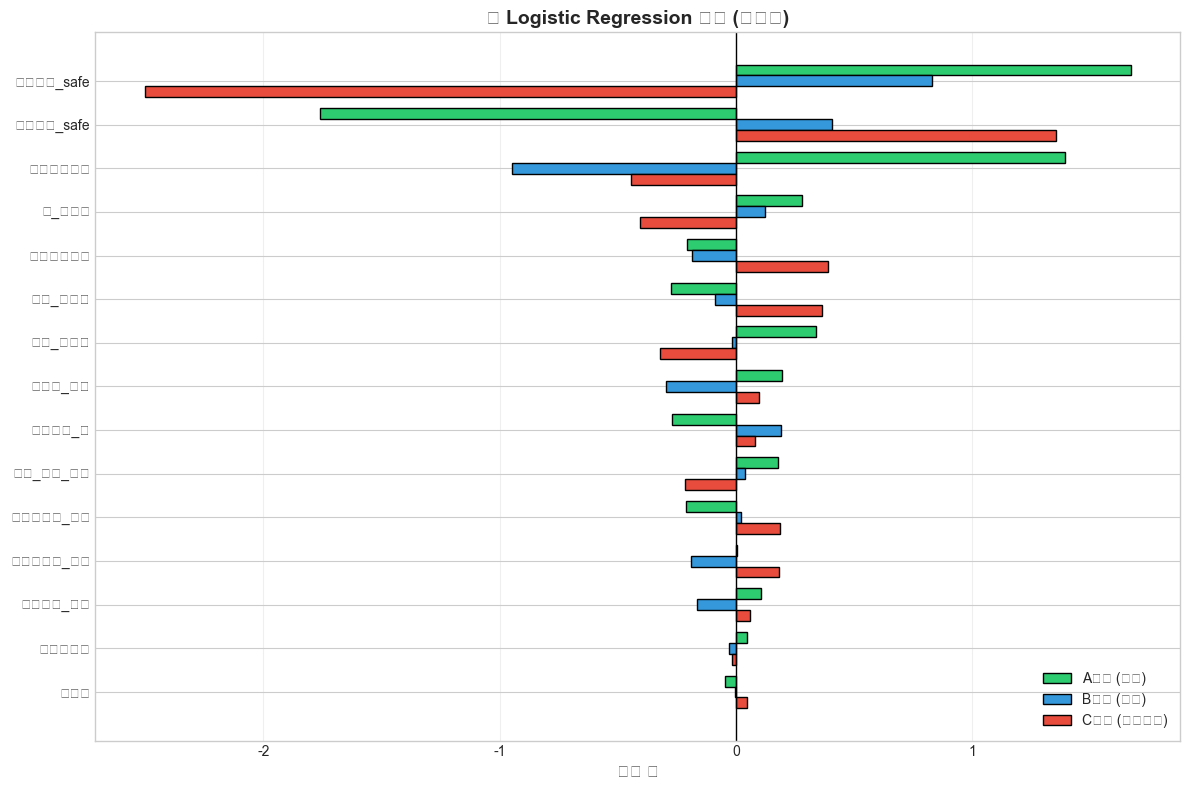

💾 그래프 저장: lr_coefficients.png


In [17]:
# LR 계수 시각화
if 'LogisticRegression' in models:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    x = np.arange(len(coef_df))
    width = 0.25
    
    bars1 = ax.barh(x - width, coef_df['A등급'], width, label='A등급 (우수)', color='#2ecc71', edgecolor='black')
    bars2 = ax.barh(x, coef_df['B등급'], width, label='B등급 (보통)', color='#3498db', edgecolor='black')
    bars3 = ax.barh(x + width, coef_df['C등급'], width, label='C등급 (개선필요)', color='#e74c3c', edgecolor='black')
    
    ax.set_yticks(x)
    ax.set_yticklabels(coef_df.index)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('계수 값', fontsize=12)
    ax.set_title('📈 Logistic Regression 계수 (등급별)', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('💾 그래프 저장: lr_coefficients.png')

---
## 📋 6. 결론 및 인사이트

### 6.1 최종 선택 모델

In [18]:
# 최고 성능 모델 선택
# 기준: 1) 과적합률 최소, 2) Test Accuracy 최대
best_idx = perf_df['과적합률'].idxmin()
best_model = perf_df.loc[best_idx]

print('=' * 70)
print('🏆 최종 선택 모델')
print('=' * 70)
print(f'\n   모델명: {best_model["모델"]}')
print(f'   Test Accuracy: {best_model["Test Accuracy"]:.4f}')
print(f'   Train Accuracy: {best_model["Train Accuracy"]:.4f}')
print(f'   과적합률: {best_model["과적합률"]:.4f}')
print(f'   CV Mean: {best_model["CV Mean"]:.4f} (±{best_model["CV Std"]:.4f})')

print('\n📌 선택 이유:')
print('   • 과적합률이 가장 낮아 일반화 성능이 우수')
print('   • Test Accuracy가 높아 실제 예측 성능이 좋음')
print('   • CV와 Test 간 차이가 작아 안정적인 성능')

🏆 최종 선택 모델

   모델명: LogisticRegression
   Test Accuracy: 0.8732
   Train Accuracy: 0.8714
   과적합률: -0.0018
   CV Mean: 0.8250 (±0.0510)

📌 선택 이유:
   • 과적합률이 가장 낮아 일반화 성능이 우수
   • Test Accuracy가 높아 실제 예측 성능이 좋음
   • CV와 Test 간 차이가 작아 안정적인 성능


### 6.2 주요 인사이트

In [19]:
print('=' * 70)
print('💡 주요 인사이트')
print('=' * 70)

insights = [
    ('1. 타겟 분포', [
        '30/40/30 분위수 기반으로 균형 잡힌 클래스 분포 생성',
        'Z-score 정규화로 지역별 편차를 보정하여 공정한 평가 가능'
    ]),
    ('2. 중요 피처', [
        '거래완료_safe, 등록매물_safe 등 거래 지표가 높은 중요도',
        '운영기간_년, 베테랑 등 경험 관련 피처가 상위권',
        '로그 변환으로 극단값 영향 최소화'
    ]),
    ('3. 모델 성능', [
        'LogisticRegression이 가장 과적합이 적고 안정적',
        'XGBoost, CatBoost는 비선형 패턴 포착에 유리',
        'Ensemble은 개별 모델 약점을 보완'
    ]),
    ('4. 과적합 방지', [
        '정규화 강화 (C=0.5, L1/L2 regularization)',
        '트리 깊이 제한 (max_depth=3~4)',
        '최소 샘플 수 증가 (min_samples_split, min_samples_leaf)'
    ])
]

for title, points in insights:
    print(f'\n📌 {title}')
    for point in points:
        print(f'   • {point}')

💡 주요 인사이트

📌 1. 타겟 분포
   • 30/40/30 분위수 기반으로 균형 잡힌 클래스 분포 생성
   • Z-score 정규화로 지역별 편차를 보정하여 공정한 평가 가능

📌 2. 중요 피처
   • 거래완료_safe, 등록매물_safe 등 거래 지표가 높은 중요도
   • 운영기간_년, 베테랑 등 경험 관련 피처가 상위권
   • 로그 변환으로 극단값 영향 최소화

📌 3. 모델 성능
   • LogisticRegression이 가장 과적합이 적고 안정적
   • XGBoost, CatBoost는 비선형 패턴 포착에 유리
   • Ensemble은 개별 모델 약점을 보완

📌 4. 과적합 방지
   • 정규화 강화 (C=0.5, L1/L2 regularization)
   • 트리 깊이 제한 (max_depth=3~4)
   • 최소 샘플 수 증가 (min_samples_split, min_samples_leaf)


### 6.3 향후 개선 방향

In [20]:
print('=' * 70)
print('🚀 향후 개선 방향')
print('=' * 70)

improvements = [
    ('데이터 측면', [
        '더 많은 데이터 수집으로 모델 일반화 성능 향상',
        '시계열 데이터 추가로 변화 추세 반영',
        '외부 데이터(리뷰, 평점) 통합'
    ]),
    ('피처 측면', [
        '추가 피처 엔지니어링 (다항 피처, 상호작용 피처)',
        '피처 선택 기법 적용 (RFE, SHAP 기반)',
        '도메인 지식 기반 신규 피처 개발'
    ]),
    ('모델 측면', [
        'Bayesian Optimization으로 하이퍼파라미터 튜닝',
        'Stacking 앙상블 적용',
        '신경망 기반 모델 실험 (TabNet, DeepFM)'
    ])
]

for title, points in improvements:
    print(f'\n📌 {title}')
    for point in points:
        print(f'   • {point}')

print('\n' + '=' * 70)
print('📊 분석 완료!')
print('=' * 70)

🚀 향후 개선 방향

📌 데이터 측면
   • 더 많은 데이터 수집으로 모델 일반화 성능 향상
   • 시계열 데이터 추가로 변화 추세 반영
   • 외부 데이터(리뷰, 평점) 통합

📌 피처 측면
   • 추가 피처 엔지니어링 (다항 피처, 상호작용 피처)
   • 피처 선택 기법 적용 (RFE, SHAP 기반)
   • 도메인 지식 기반 신규 피처 개발

📌 모델 측면
   • Bayesian Optimization으로 하이퍼파라미터 튜닝
   • Stacking 앙상블 적용
   • 신경망 기반 모델 실험 (TabNet, DeepFM)

📊 분석 완료!


---

## 📁 생성된 파일 목록

이 분석에서 생성된 이미지 파일:

1. `target_distribution.png` - 타겟 등급 분포
2. `zscore_distribution.png` - Z-score 분포 및 등급 경계
3. `feature_distributions.png` - 15개 피처 분포
4. `feature_correlation_heatmap.png` - 피처 상관관계 히트맵
5. `model_comparison.png` - 모델 성능 비교
6. `feature_importance.png` - 피처 중요도 순위
7. `lr_coefficients.png` - Logistic Regression 계수

---

*분석 완료 - 2024년 12월*